**Objective**

The objective of this project is to analyze healthcare data using Python, Exploratory Data Analysis (EDA).

The project focuses on understanding patient demographics, medical conditions, admission patterns, billing amounts, length of hospital stay, test results, and other healthcare-related factors.

The cleaned and analyzed data will be used to generate meaningful insights and build an interactive Power BI dashboard.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/healthcare_dataset.csv")

In [ ]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328.0,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265.0,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205.0,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450.0,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458.0,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6932 entries, 0 to 6931
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                6932 non-null   object 
 1   Age                 6932 non-null   int64  
 2   Gender              6932 non-null   object 
 3   Blood Type          6932 non-null   object 
 4   Medical Condition   6932 non-null   object 
 5   Date of Admission   6932 non-null   object 
 6   Doctor              6932 non-null   object 
 7   Hospital            6932 non-null   object 
 8   Insurance Provider  6932 non-null   object 
 9   Billing Amount      6932 non-null   float64
 10  Room Number         6931 non-null   float64
 11  Admission Type      6931 non-null   object 
 12  Discharge Date      6931 non-null   object 
 13  Medication          6931 non-null   object 
 14  Test Results        6931 non-null   object 
dtypes: float64(2), int64(1), object(12)
memory usage: 812.5

In [ ]:
df.shape

(6932, 15)

**Dataset Description**

The dataset contains healthcare records of patients, including demographic information, medical conditions, admission details, billing information, insurance providers, medications, and test results.

The original dataset contains 15 columns and approximately 50,000 records.

Key columns include:
- Age
- Gender
- Blood Type
- Medical Condition
- Date of Admission
- Doctor
- Hospital
- Insurance Provider
- Billing Amount
- Admission Type
- Discharge Date
- Medication
- Test Results

<Axes: >

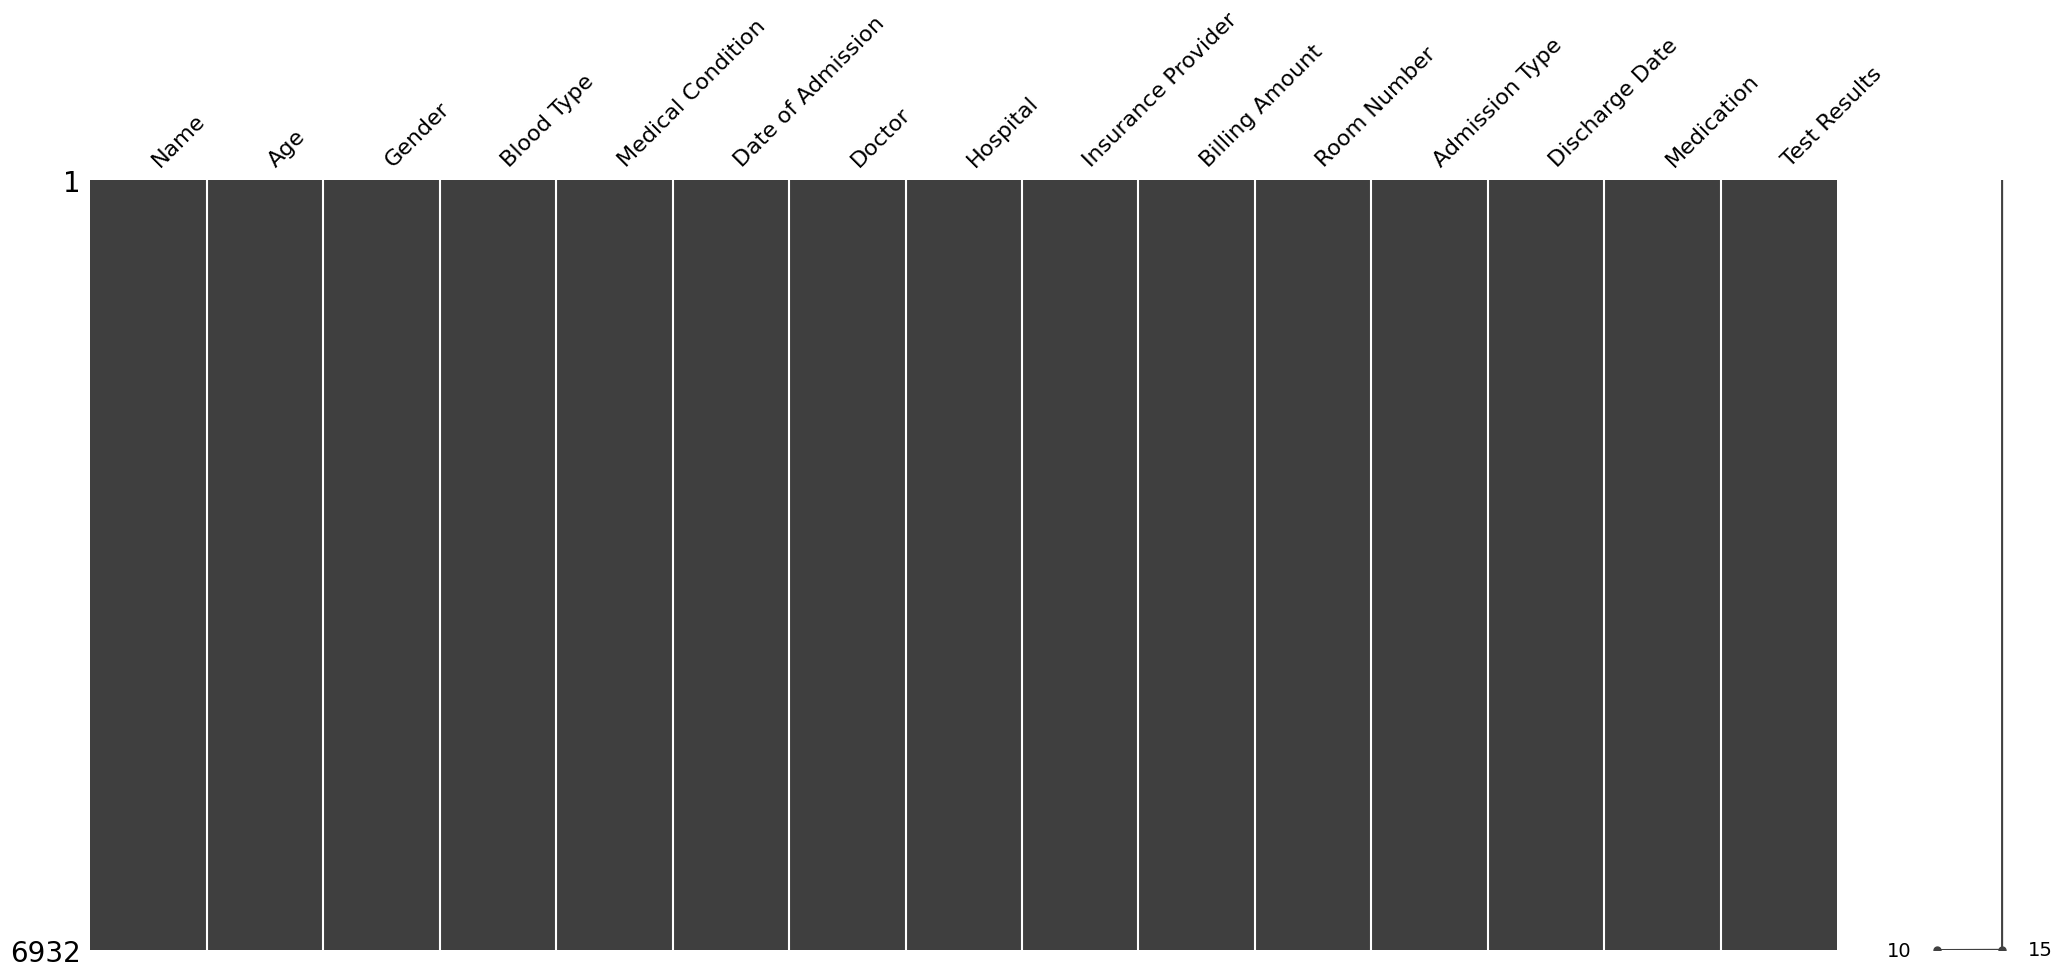

In [ ]:
import missingno as msn
msn.matrix(df)

In [ ]:
df.isnull().sum()/len(df)*100

,0
Name,0.000000
Age,0.000000
Gender,0.000000
Blood Type,0.000000
Medical Condition,0.000000
Date of Admission,0.000000
Doctor,0.000000
Hospital,0.000000
Insurance Provider,0.000000
Billing Amount,0.000000


In [ ]:
df = df.drop(columns=['Name', 'Room Number'])

In [ ]:
df.shape

(6932, 13)

In [ ]:
categorical_columns = ['Admission Type', 'Medication', 'Test Results']

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0
Admission Type,0


In [ ]:
df[df['Discharge Date'].isnull()]

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results
6931,32,Female,A-,Cancer,2019-06-11,Christina Schmidt,Peterson-Hodges,UnitedHealthcare,29685.403044,Elective,NaT,Penicillin,Abnormal


In [ ]:
df = df.dropna(subset=['Discharge Date'])

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0
Admission Type,0


In [ ]:
df.shape

(6931, 13)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Age,int64
Gender,object
Blood Type,object
Medical Condition,object
Date of Admission,datetime64[ns]
Doctor,object
Hospital,object
Insurance Provider,object
Billing Amount,float64
Admission Type,object


In [ ]:
df['Age'].describe()

,Age
count,6931.000000
mean,51.900880
std,19.766461
min,18.000000
25%,35.000000
50%,52.000000
75%,69.000000
max,85.000000


In [ ]:
df['Billing Amount'].describe()

,Billing Amount
count,6931.000000
mean,25616.806598
std,14166.345646
min,-1310.272895
25%,13350.229363
50%,25722.583531
75%,37745.111479
max,52271.663747


**Data Cleaning**

Data cleaning was performed to improve data quality and prepare the dataset for further analysis.

The following steps were performed:

1. Removed unnecessary columns such as Name and Room Number.
2. Checked for missing values.
3. Filled missing categorical values using the mode.
4. Converted admission and discharge dates into datetime format.
5. Removed the record with a missing discharge date.
6. Checked and confirmed that there were no duplicate records.
7. Validated the Age column for reasonable values.
8. Identified and removed negative billing amounts.
9. Validated categorical columns such as Admission Type, Medical Condition, and Test Results.

In [ ]:
(df['Billing Amount'] < 0).sum()

np.int64(13)

In [ ]:
df[df['Billing Amount'] < 0][['Age', 'Gender', 'Medical Condition', 'Billing Amount', 'Admission Type']]

,Age,Gender,Medical Condition,Billing Amount,Admission Type
132,32,Female,Cancer,-502.507813,Urgent
799,49,Female,Asthma,-1018.245371,Elective
1018,60,Male,Hypertension,-306.364925,Elective
1421,74,Female,Asthma,-109.097122,Emergency
2103,72,Female,Diabetes,-576.727907,Urgent
2696,74,Male,Diabetes,-135.986000,Elective
2855,39,Female,Hypertension,-370.983674,Elective
3772,77,Male,Obesity,-1310.272895,Elective
5445,32,Male,Arthritis,-692.408820,Elective
5708,23,Male,Diabetes,-353.865186,Elective


In [ ]:
df = df[df['Billing Amount'] >= 0]

In [ ]:
df['Billing Amount'].describe()

,Billing Amount
count,6918.000000
mean,25665.858259
std,14134.331410
min,42.514589
25%,13400.569246
50%,25783.210541
75%,37774.166029
max,52271.663747


In [ ]:
df['Admission Type'].value_counts()

,count
Admission Type,
Elective,2348
Urgent,2297
Emergency,2273


In [ ]:
df['Medical Condition'].value_counts()

,count
Medical Condition,
Arthritis,1159
Asthma,1158
Cancer,1156
Diabetes,1152
Hypertension,1152
Obesity,1141


In [ ]:
df['Test Results'].value_counts()

,count
Test Results,
Abnormal,2360
Inconclusive,2302
Normal,2256


**Categorical Data Validation**

The `value_counts()` function was used to identify the frequency of each category in categorical columns.

It helped verify whether the columns contained expected categories and identify any unexpected or inconsistent values.

For example, it was used for:
- Admission Type
- Medical Condition
- Test Results

In [ ]:
df['Length of Stay'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

In [ ]:
df['Length of Stay'].describe()

,Length of Stay
count,6918.000000
mean,15.509974
std,8.600181
min,1.000000
25%,8.000000
50%,16.000000
75%,23.000000
max,30.000000


In [ ]:
print("Negative Length of Stay:", (df['Length of Stay'] < 0).sum())
print("Zero Length of Stay:", (df['Length of Stay'] == 0).sum())

Negative Length of Stay: 0
Zero Length of Stay: 0


In [ ]:
df['Admission Year'] = df['Date of Admission'].dt.year
df['Admission Month'] = df['Date of Admission'].dt.month

In [ ]:
df[['Date of Admission', 'Admission Year', 'Admission Month']].head()

,Date of Admission,Admission Year,Admission Month
0,2024-01-31,2024,1
1,2019-08-20,2019,8
2,2022-09-22,2022,9
3,2020-11-18,2020,11
4,2022-09-19,2022,9


**Exploratory Data Analysis (EDA)**

Exploratory Data Analysis is performed to understand the distribution, patterns, and characteristics of the healthcare data.

The analysis includes patient demographics, medical conditions, admission patterns, billing amounts, length of stay, and test results.

**Patient Age Distribution**

Age distribution is analyzed to understand the age groups represented in the healthcare dataset.

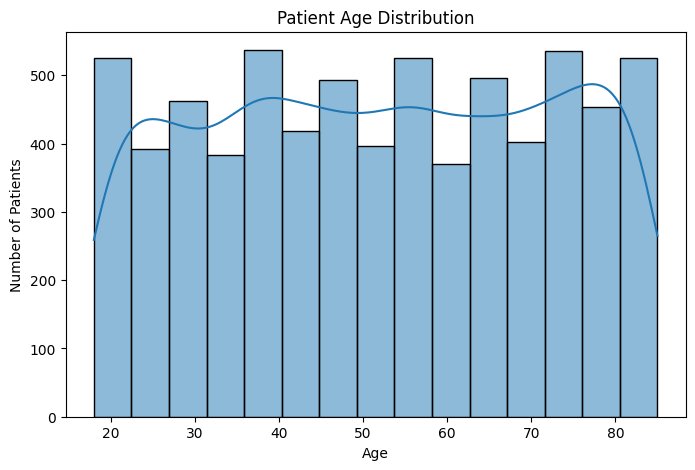

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=15, kde=True)

plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

**Insight**

The patients in the dataset are between 18 and 85 years old. The average patient age is approximately 52 years, while the median age is 52 years. This indicates that the dataset represents a wide range of adult age groups, with patients distributed across both younger and older age groups.

**Gender Distribution**

Gender distribution is analyzed to understand the representation of different genders among the patients in the dataset.

In [ ]:
df['Gender'].value_counts()


,count
Gender,
Male,3461
Female,3457


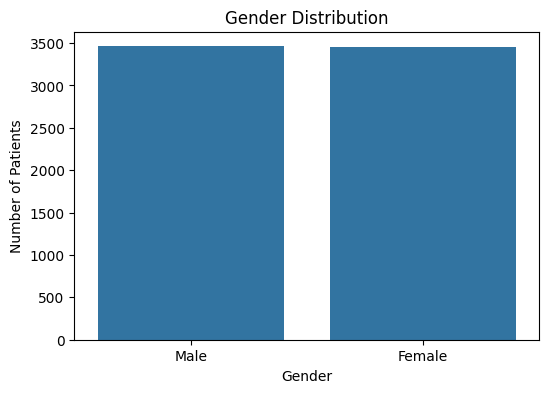

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Gender')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

plt.show()

**Insight**

The dataset shows a nearly balanced distribution of male and female patients. This indicates that neither gender is heavily overrepresented in the dataset.

**Medical Condition Distribution**

Medical condition distribution is analyzed to understand the frequency of different medical conditions among the patients.

In [ ]:
df['Medical Condition'].value_counts()

,count
Medical Condition,
Arthritis,1159
Asthma,1158
Cancer,1156
Diabetes,1152
Hypertension,1152
Obesity,1141


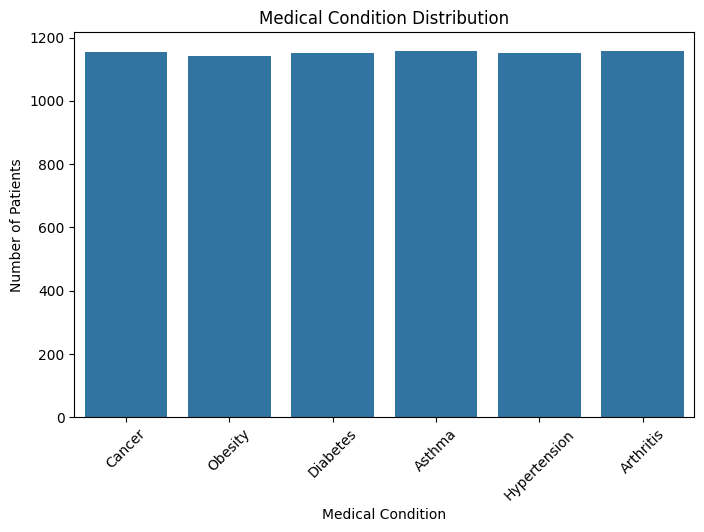

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Medical Condition')

plt.title('Medical Condition Distribution')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

plt.show()

**Insight**

The distribution of medical conditions is nearly balanced, with all six conditions having a similar number of patient records. No single medical condition significantly dominates the dataset.

**Admission Type Distribution**

Admission type is analyzed to understand how patients were admitted to the hospital, such as Emergency, Urgent, or Elective admission.

In [ ]:
df['Admission Type'].value_counts()

,count
Admission Type,
Elective,2348
Urgent,2297
Emergency,2273


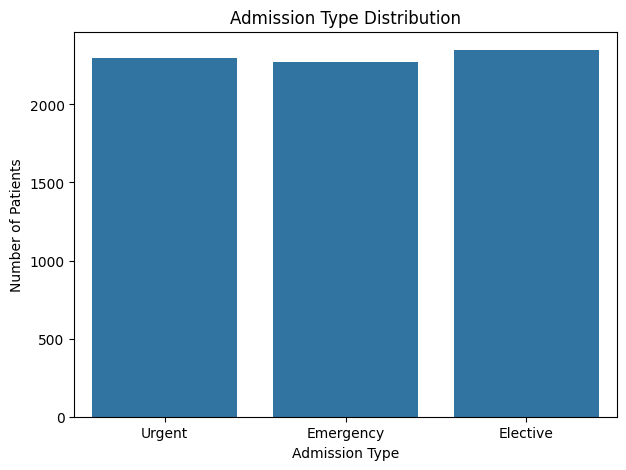

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Admission Type')

plt.title('Admission Type Distribution')
plt.xlabel('Admission Type')
plt.ylabel('Number of Patients')

plt.show()

**Insight**

Elective admissions have the highest number of patient records, followed by Urgent and Emergency admissions. However, the differences between the three admission types are relatively small, indicating a fairly balanced distribution.

**Billing Amount Distribution**

Billing amount is analyzed to understand the distribution of healthcare costs across patient records and identify the typical billing range.

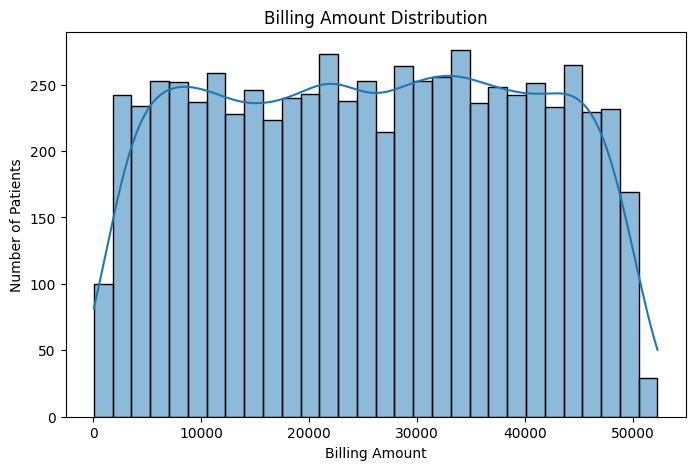

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Billing Amount'], bins=30, kde=True)

plt.title('Billing Amount Distribution')
plt.xlabel('Billing Amount')
plt.ylabel('Number of Patients')

plt.show()

**Insight**

The billing amounts range from approximately 42.51 to 52,271.66. The average billing amount is around 25,665.86, which is close to the median of 25,783.21. This indicates that the billing amounts are centered around the mid-range of the observed values.

**Length of Stay Distribution**

Length of Stay represents the number of days a patient stayed in the hospital. It is analyzed to understand the distribution of hospital stay durations.

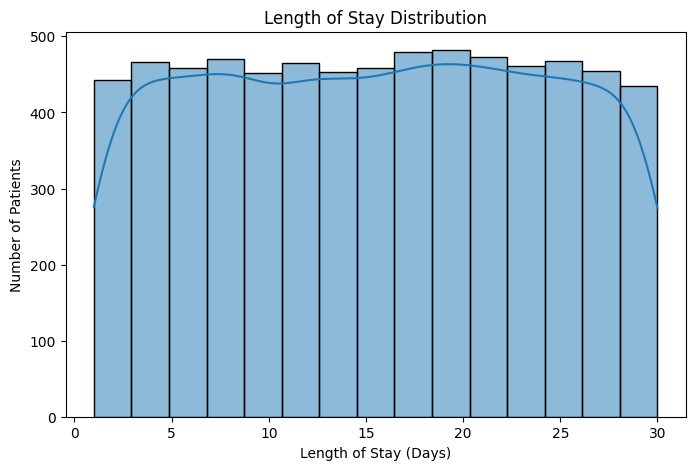

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Length of Stay'], bins=15, kde=True)

plt.title('Length of Stay Distribution')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Number of Patients')

plt.show()

**Insight**

The length of hospital stay ranges from 1 to 30 days. The average stay is approximately 15.5 days, while the median stay is 16 days. This indicates that patient stays are generally centered around the middle of the 1–30 day range.

**Insurance Provider Distribution**

Insurance provider distribution is analyzed to understand the representation of different insurance providers among the patients.

In [ ]:
df['Insurance Provider'].value_counts()

,count
Insurance Provider,
Cigna,1406
Blue Cross,1395
Medicare,1378
UnitedHealthcare,1370
Aetna,1369


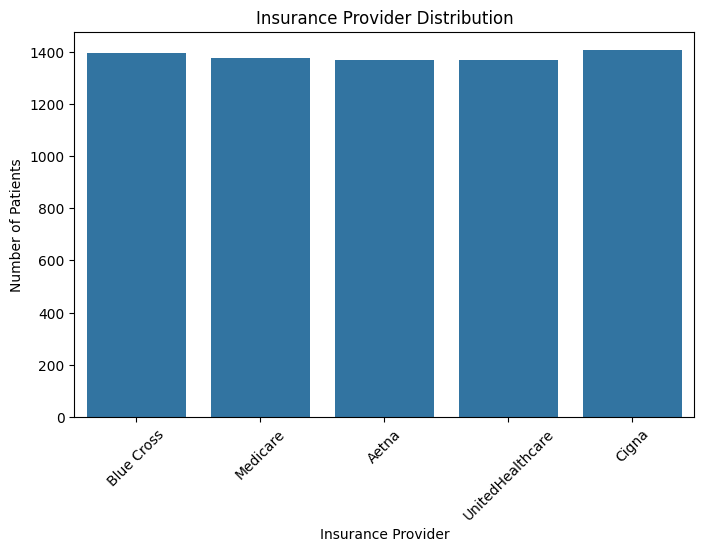

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Insurance Provider')

plt.title('Insurance Provider Distribution')
plt.xlabel('Insurance Provider')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

plt.show()

**Insight**

The healthcare dataset includes multiple insurance providers, with patient records distributed across the different providers. The distribution is relatively balanced, indicating that no single insurance provider overwhelmingly dominates the dataset.

**Medication Distribution**

Medication distribution is analyzed to understand the frequency of different medications prescribed to patients in the dataset.

In [ ]:
df['Medication'].value_counts()

,count
Medication,
Penicillin,1428
Ibuprofen,1408
Lipitor,1387
Aspirin,1355
Paracetamol,1340


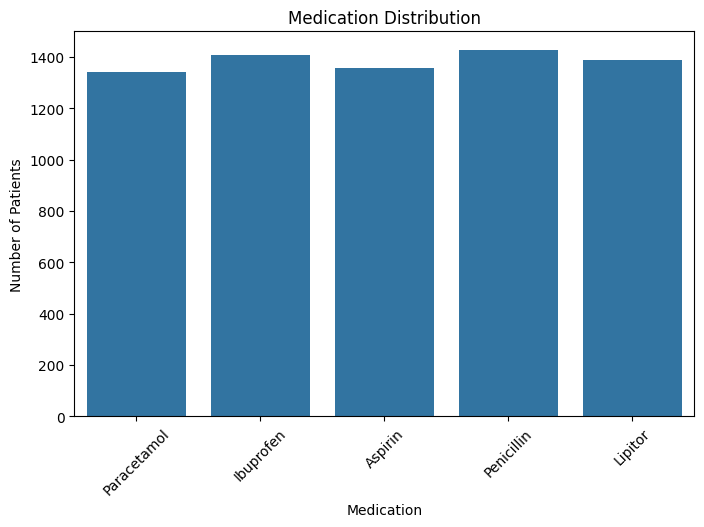

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Medication')

plt.title('Medication Distribution')
plt.xlabel('Medication')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

plt.show()

**Insight**

The dataset contains multiple medications prescribed to patients, with the records distributed across the different medication categories. The medication distribution is relatively balanced, with no single medication category accounting for a very large share of the patient records.

**Blood Type Distribution**

Blood type distribution is analyzed to understand the representation of different blood groups among the patients in the dataset.

In [ ]:
df['Blood Type'].value_counts()

,count
Blood Type,
A+,884
B+,884
AB+,883
O+,881
AB-,863
A-,856
O-,835
B-,832


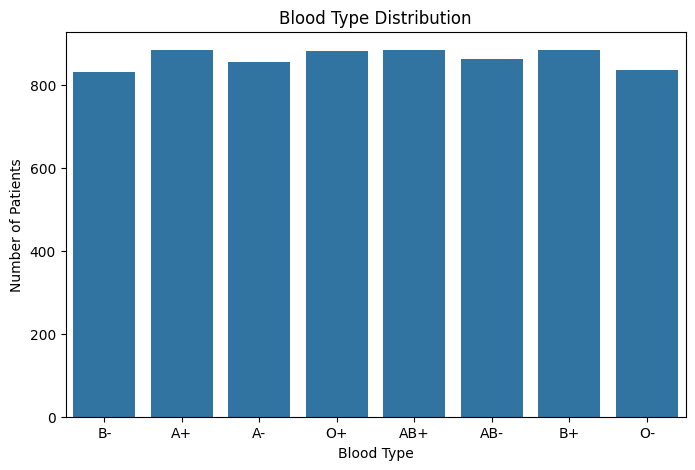

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Blood Type')

plt.title('Blood Type Distribution')
plt.xlabel('Blood Type')
plt.ylabel('Number of Patients')

plt.show()

**Insight**

The dataset contains all major blood type categories, and the patient records are distributed fairly evenly across the different blood types. No single blood type has a significantly higher representation than the others.

**Admissions Over Time**

Admission trends are analyzed to understand how the number of hospital admissions changes over different years.

In [ ]:
admission_year_counts = df['Admission Year'].value_counts().sort_index()

admission_year_counts

,count
Admission Year,
2019,932
2020,1428
2021,1329
2022,1417
2023,1316
2024,496


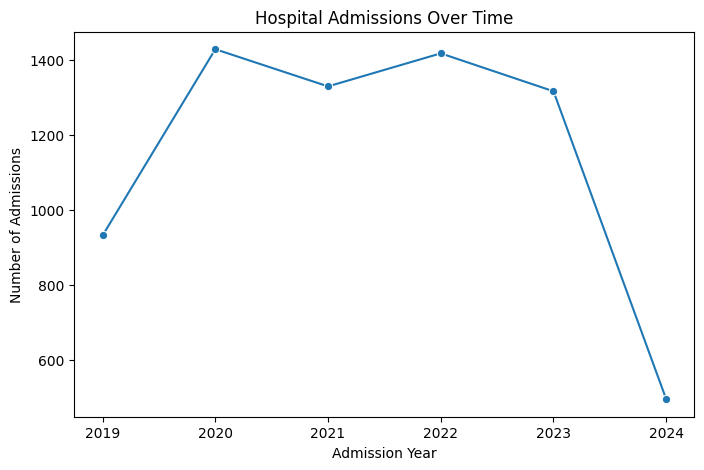

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=admission_year_counts.index,
    y=admission_year_counts.values,
    marker='o'
)

plt.title('Hospital Admissions Over Time')
plt.xlabel('Admission Year')
plt.ylabel('Number of Admissions')

plt.show()

**Insight**

The number of hospital admissions varies across the years in the dataset. The yearly trend shows changes in admission volume over time, which can help identify periods with relatively higher or lower patient admissions.

**Average Billing Amount by Medical Condition**

The average billing amount is analyzed across different medical conditions to compare healthcare costs associated with each condition.

In [ ]:
avg_billing_condition = (
    df.groupby('Medical Condition')['Billing Amount']
    .mean()
    .sort_values(ascending=False)
)

avg_billing_condition

,Billing Amount
Medical Condition,
Asthma,26027.310824
Cancer,26000.473454
Arthritis,25772.182780
Hypertension,25594.810342
Obesity,25486.768314
Diabetes,25108.203288


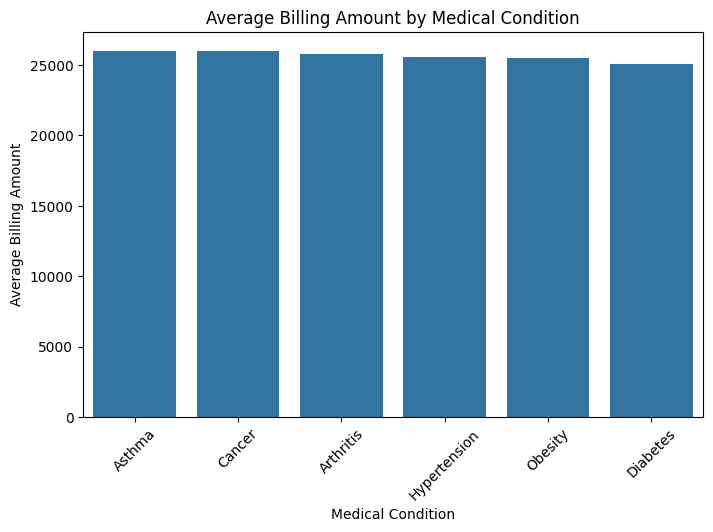

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_billing_condition.index,
    y=avg_billing_condition.values
)

plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)

plt.show()

**Insight**

The average billing amount varies across different medical conditions. This indicates that healthcare costs are not exactly the same for all conditions, and some conditions have relatively higher average billing amounts than others.

**Average Length of Stay by Medical Condition**

The average length of hospital stay is analyzed across different medical conditions to compare the typical duration of hospitalization for each condition.

In [ ]:
avg_stay_condition = (
    df.groupby('Medical Condition')['Length of Stay']
    .mean()
    .sort_values(ascending=False)
)

avg_stay_condition

,Length of Stay
Medical Condition,
Asthma,15.945596
Cancer,15.683391
Obesity,15.602980
Hypertension,15.420139
Arthritis,15.361519
Diabetes,15.045139


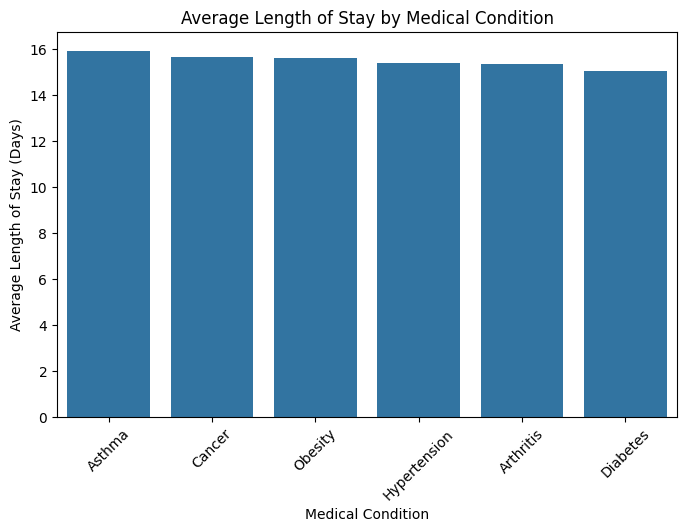

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_stay_condition.index,
    y=avg_stay_condition.values
)

plt.title('Average Length of Stay by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Length of Stay (Days)')
plt.xticks(rotation=45)

plt.show()

**Insight**

The average length of hospital stay varies across different medical conditions. Some conditions have relatively longer average stays, while others have shorter stays. This indicates that the duration of hospitalization differs depending on the medical condition.

**Test Results by Medical Condition**

Test results are analyzed across different medical conditions to understand the distribution of Normal, Abnormal, and Inconclusive results for each condition.

In [ ]:
test_condition = pd.crosstab(
    df['Medical Condition'],
    df['Test Results']
)

test_condition

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,402,399,358
Asthma,404,372,382
Cancer,409,378,369
Diabetes,384,381,387
Hypertension,392,386,374
Obesity,369,386,386


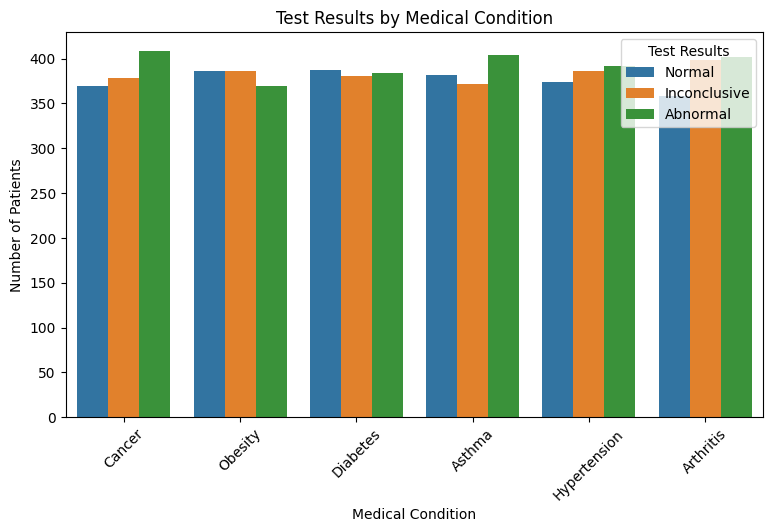

In [ ]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Medical Condition',
    hue='Test Results'
)

plt.title('Test Results by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

plt.show()

**Insight**

Test results vary across the different medical conditions. Each medical condition contains Normal, Abnormal, and Inconclusive results, with differences in their counts across conditions. This helps compare test-result patterns for different medical conditions.

**Average Billing Amount by Admission Type**

The average billing amount is analyzed across different admission types to compare healthcare costs associated with Emergency, Urgent, and Elective admissions.

In [ ]:
avg_billing_admission = (
    df.groupby('Admission Type')['Billing Amount']
    .mean()
    .sort_values(ascending=False)
)

avg_billing_admission

,Billing Amount
Admission Type,
Urgent,25867.621917
Elective,25580.796042
Emergency,25549.833166


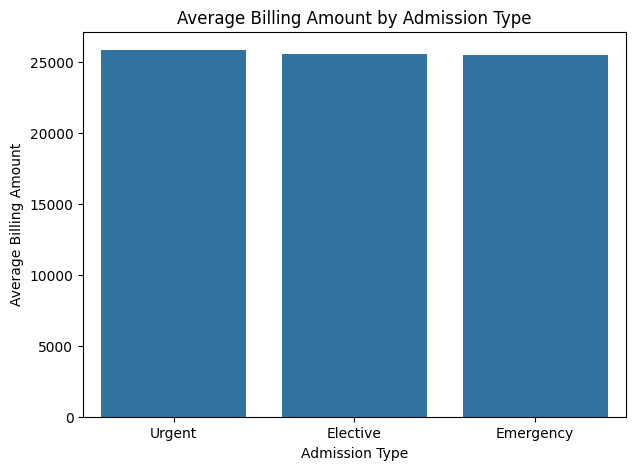

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=avg_billing_admission.index,
    y=avg_billing_admission.values
)

plt.title('Average Billing Amount by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Average Billing Amount')

plt.show()

**Insight**

The average billing amount differs across Emergency, Urgent, and Elective admissions. This shows that healthcare costs vary depending on the type of hospital admission, with some admission types having relatively higher average billing amounts than others.

**Average Length of Stay by Admission Type**

The average length of hospital stay is analyzed across different admission types to compare the typical hospitalization duration for Emergency, Urgent, and Elective admissions.

In [ ]:
avg_stay_admission = (
    df.groupby('Admission Type')['Length of Stay']
    .mean()
    .sort_values(ascending=False)
)

avg_stay_admission

,Length of Stay
Admission Type,
Elective,15.563032
Emergency,15.536296
Urgent,15.429691


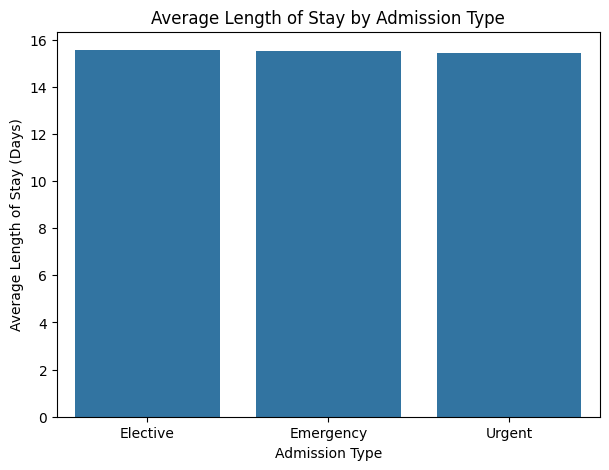

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=avg_stay_admission.index,
    y=avg_stay_admission.values
)

plt.title('Average Length of Stay by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Average Length of Stay (Days)')

plt.show()

**Insight**

The average length of hospital stay differs across Emergency, Urgent, and Elective admissions. This indicates that the duration of hospitalization varies depending on the type of admission.

**Monthly Admission Trend**

Monthly admission trends are analyzed to understand how hospital admissions vary across different months of the year.

In [ ]:
monthly_admissions = (
    df['Admission Month']
    .value_counts()
    .sort_index()
)

monthly_admissions

,count
Admission Month,
1,609
2,524
3,612
4,536
5,604
6,569
7,595
8,644
9,526


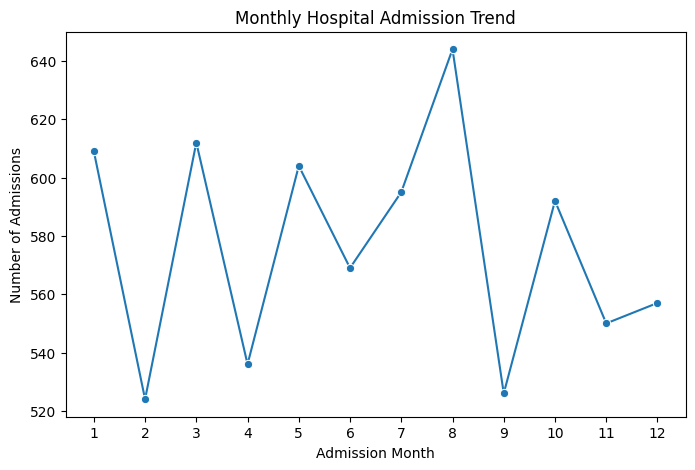

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=monthly_admissions.index,
    y=monthly_admissions.values,
    marker='o'
)

plt.title('Monthly Hospital Admission Trend')
plt.xlabel('Admission Month')
plt.ylabel('Number of Admissions')

plt.xticks(range(1, 13))

plt.show()

**Insight**

Hospital admissions vary across the different months of the year. The monthly trend shows that some months have relatively higher admission volumes, while others have lower volumes. This helps identify seasonal variations in hospital admissions.

**Correlation Analysis**

Correlation analysis is used to understand the relationship between numerical variables in the healthcare dataset.

It helps identify whether changes in one numerical variable are associated with changes in another variable.

In [ ]:
numeric_columns = [
    'Age',
    'Billing Amount',
    'Length of Stay'
]

correlation = df[numeric_columns].corr()

correlation

,Age,Billing Amount,Length of Stay
Age,1.000000,-0.003473,0.007469
Billing Amount,-0.003473,1.000000,0.018574
Length of Stay,0.007469,0.018574,1.000000


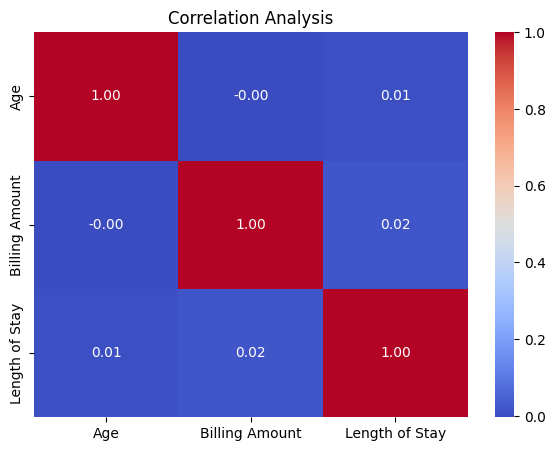

In [ ]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Analysis')
plt.show()

**Insight**

The correlation analysis shows the relationships between Age, Billing Amount, and Length of Stay. The correlation values indicate that these variables have varying degrees of relationship with each other. Overall, no strong relationship should be assumed without considering the actual correlation values.

**Save Cleaned Dataset**

After completing data cleaning and feature engineering, the cleaned dataset is exported as a CSV file.

This cleaned dataset will be used for SQL analysis and Power BI dashboard development.

In [ ]:
df.to_csv('healthcare_cleaned.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'healthcare_dataset.csv', 'healthcare_cleaned.csv', 'sample_data']
